# **Mount Google Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Import Semua Library**

In [2]:
import cv2
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from skimage import feature

# **Definisi Path Dataset**

In [3]:
dataset_path = '/content/drive/MyDrive/Colab Notebooks/TanamanHerbal'

print(f"Path dataset: {dataset_path}")

Path dataset: /content/drive/MyDrive/Colab Notebooks/TanamanHerbal


# **Load dan Bersihkan Label**

In [4]:
# Ambil semua file gambar
all_files = [f for f in os.listdir(dataset_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
print(f"Total gambar ditemukan: {len(all_files)}")

# Fungsi untuk extract dan membersihkan label
def extract_and_clean_label(filename):
    match = re.match(r'([a-zA-Z\s]+?)\s*\(\d+\)', filename)
    if match:
        label = match.group(1).strip().lower()
        # Perbaikan typo label
        label_map = {
            'teh hijauu': 'teh hijau',
            'sirsakk': 'sirsak',
            'kari': 'kari'
        }
        cleaned_label = label_map.get(label, label)
        return cleaned_label.title()  # Huruf pertama kapital
    return None

# Buat DataFrame
data = []
for f in all_files:
    label = extract_and_clean_label(f)
    if label:
        data.append((f, label))

df = pd.DataFrame(data, columns=['filename', 'label'])

print("\nDistribusi Label setelah diperbaiki:")
print(df['label'].value_counts())

Total gambar ditemukan: 200

Distribusi Label setelah diperbaiki:
label
Jambu Biji      20
Kari            20
Daun Kemangi    20
Kunyit          20
Mint            20
Pepaya          20
Sirih           20
Sirsak          20
Lidah Buaya     20
Teh Hijau       20
Name: count, dtype: int64


# **EDA (Exploratory Data Analysis)**

/tmp/ipykernel_2631/985440478.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['label'], order=df['label'].value_counts().index, palette='viridis')


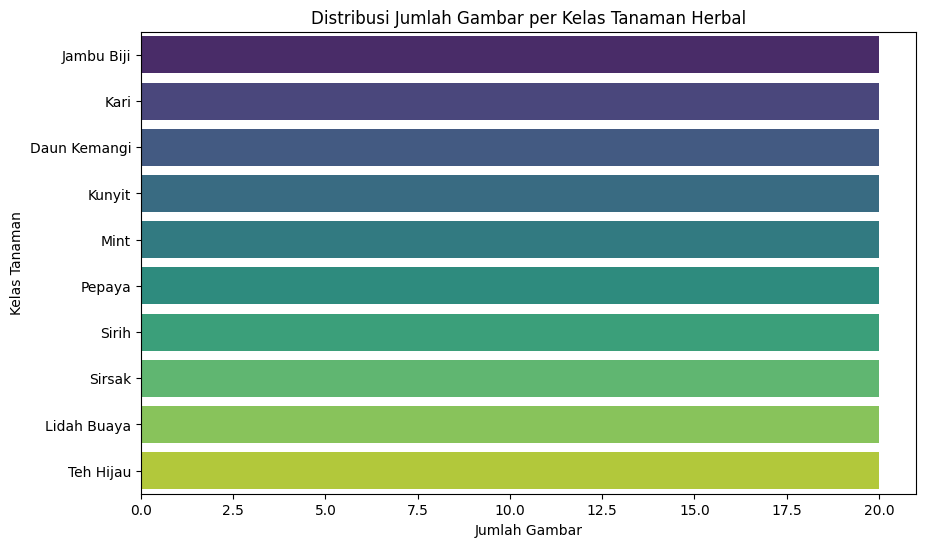


Contoh data:
               filename       label
0   jambu biji (82).JPG  Jambu Biji
1   jambu biji (81).JPG  Jambu Biji
2  jambu biji (100).JPG  Jambu Biji
3   jambu biji (83).JPG  Jambu Biji
4   jambu biji (84).JPG  Jambu Biji


In [5]:
# Visualisasi distribusi kelas
plt.figure(figsize=(10, 6))
sns.countplot(y=df['label'], order=df['label'].value_counts().index, palette='viridis')
plt.title('Distribusi Jumlah Gambar per Kelas Tanaman Herbal')
plt.xlabel('Jumlah Gambar')
plt.ylabel('Kelas Tanaman')
plt.show()

# Tampilkan 5 baris pertama
print("\nContoh data:")
print(df.head())

# **Fungsi Ekstraksi Fitur**

In [6]:
def extract_features(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 1. Fitur Warna
    mean_rgb = np.mean(img_rgb, axis=(0,1))
    std_rgb  = np.std(img_rgb, axis=(0,1))
    mean_hsv = np.mean(img_hsv, axis=(0,1))
    std_hsv  = np.std(img_hsv, axis=(0,1))

    # Histogram warna (16 bins)
    hist_r = np.histogram(img_rgb[:,:,0], bins=16, range=(0,255))[0]
    hist_g = np.histogram(img_rgb[:,:,1], bins=16, range=(0,255))[0]
    hist_b = np.histogram(img_rgb[:,:,2], bins=16, range=(0,255))[0]
    hist_features = np.concatenate([hist_r, hist_g, hist_b])

    # 2. Fitur Tekstur (GLCM)
    glcm = feature.graycomatrix(gray, distances=[1], angles=[0], levels=256,
                                symmetric=True, normed=True)
    contrast = feature.graycoprops(glcm, 'contrast')[0,0]
    dissimilarity = feature.graycoprops(glcm, 'dissimilarity')[0,0]
    homogeneity = feature.graycoprops(glcm, 'homogeneity')[0,0]
    energy = feature.graycoprops(glcm, 'energy')[0,0]
    correlation = feature.graycoprops(glcm, 'correlation')[0,0]

    # 3. Fitur Bentuk
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = np.ones((5,5), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        area = perimeter = diameter = solidity = roundness = 0
    else:
        cnt = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(cnt)
        perimeter = cv2.arcLength(cnt, True)
        diameter = np.sqrt(4 * area / np.pi) if perimeter > 0 else 0
        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        solidity = area / hull_area if hull_area > 0 else 0
        roundness = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0

    # Gabungkan semua fitur
    features = np.concatenate([
        mean_rgb, std_rgb,          # 6
        mean_hsv, std_hsv,          # 6
        hist_features,              # 48
        [contrast, dissimilarity, homogeneity, energy, correlation],  # 5
        [area, perimeter, diameter, solidity, roundness]              # 5
    ])

    return features

# **Ekstraksi Fitur dari Semua Gambar**

In [7]:
feature_list = []
labels = []
valid_files = []

print("Memulai proses ekstraksi fitur...")

for idx, row in df.iterrows():
    img_path = os.path.join(dataset_path, row['filename'])
    feat = extract_features(img_path)

    if feat is not None:
        feature_list.append(feat)
        labels.append(row['label'])
        valid_files.append(row['filename'])

    if (idx + 1) % 50 == 0:
        print(f"Proses: {idx+1}/{len(df)} selesai")

X = np.array(feature_list)
y = np.array(labels)

print(f"\nEkstraksi fitur selesai!")
print(f"Total data: {X.shape[0]} gambar")
print(f"Jumlah fitur per gambar: {X.shape[1]}")

Memulai proses ekstraksi fitur...
Proses: 50/200 selesai
Proses: 100/200 selesai
Proses: 150/200 selesai
Proses: 200/200 selesai

Ekstraksi fitur selesai!
Total data: 200 gambar
Jumlah fitur per gambar: 70


# **Simpan Fitur ke CSV**

In [8]:
# Buat folder hasil
save_folder = '/content/drive/MyDrive/Colab Notebooks/HasilTanamanHerbal'
os.makedirs(save_folder, exist_ok=True)

# 1. Buat daftar nama kolom agar tidak menjadi angka 0, 1, 2, dst.
feature_cols = []
feature_cols.extend([f'mean_rgb_{c}' for c in ['R','G','B']])
feature_cols.extend([f'std_rgb_{c}' for c in ['R','G','B']])
feature_cols.extend([f'mean_hsv_{c}' for c in ['H','S','V']])
feature_cols.extend([f'std_hsv_{c}' for c in ['H','S','V']])
feature_cols.extend([f'hist_rgb_{i}' for i in range(48)])
feature_cols.extend(['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation'])
feature_cols.extend(['area', 'perimeter', 'diameter', 'solidity', 'roundness'])

# 2. Simpan fitur + label + filename
feature_df = pd.DataFrame(X, columns=feature_cols)

feature_df['label'] = y
feature_df['filename'] = valid_files

# Simpan ke CSV
feature_path = os.path.join(save_folder, 'features_tanaman_herbal.csv')
feature_df.to_csv(feature_path, index=False)

# **Label Encoding & Data Splitting**

In [9]:
# Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Kelas yang dikenali:")
print(le.classes_)

# Split data: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y_encoded,
                                                    test_size=0.3,
                                                    stratify=y_encoded,
                                                    random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp,
                                                test_size=0.5,
                                                stratify=y_temp,
                                                random_state=42)

print(f"Train: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}")

Kelas yang dikenali:
['Daun Kemangi' 'Jambu Biji' 'Kari' 'Kunyit' 'Lidah Buaya' 'Mint' 'Pepaya'
 'Sirih' 'Sirsak' 'Teh Hijau']
Train: 140 | Validation: 30 | Test: 30


# **Scaling Fitur**

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# **Training SVM dengan GridSearch**

In [11]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

print("Sedang melakukan GridSearchCV...")

svm = SVC(random_state=42)
grid_search = GridSearchCV(svm, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print("Best Parameters :", grid_search.best_params_)
print("Best CV Accuracy: {:.4f}".format(grid_search.best_score_))

best_svm = grid_search.best_estimator_

Sedang melakukan GridSearchCV...
Best Parameters : {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV Accuracy: 0.6573


# **Evaluasi Model**

In [12]:
# Prediksi
y_val_pred = best_svm.predict(X_val_scaled)
y_test_pred = best_svm.predict(X_test_scaled)

# Akurasi
print(f"Validation Accuracy : {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Test Accuracy       : {accuracy_score(y_test, y_test_pred):.4f}")

# Classification Report
print("CLASSIFICATION REPORT")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

Validation Accuracy : 0.7667
Test Accuracy       : 0.7667
CLASSIFICATION REPORT
              precision    recall  f1-score   support

Daun Kemangi       0.40      0.67      0.50         3
  Jambu Biji       0.67      0.67      0.67         3
        Kari       1.00      1.00      1.00         3
      Kunyit       1.00      0.67      0.80         3
 Lidah Buaya       0.00      0.00      0.00         3
        Mint       0.67      0.67      0.67         3
      Pepaya       1.00      1.00      1.00         3
       Sirih       1.00      1.00      1.00         3
      Sirsak       0.75      1.00      0.86         3
   Teh Hijau       0.75      1.00      0.86         3

    accuracy                           0.77        30
   macro avg       0.72      0.77      0.73        30
weighted avg       0.72      0.77      0.73        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# **Confusion Matrix**

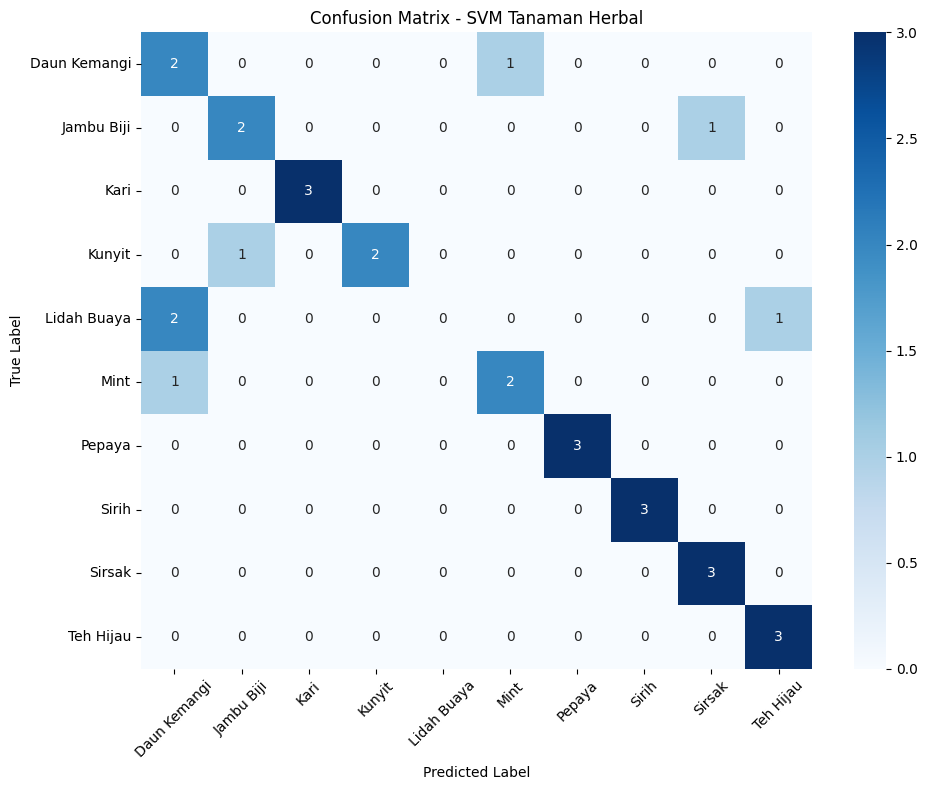

In [13]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - SVM Tanaman Herbal')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()